In [16]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("imakash3011/customer-personality-analysis")

print("Path to dataset files:", path)

Path to dataset files: /Users/ducnguyen/.cache/kagglehub/datasets/imakash3011/customer-personality-analysis/versions/1


In [17]:
import pandas as pd
import os

# This dataset's file is tab-separated
df = pd.read_csv(os.path.join(path, "marketing_campaign.csv"), sep="\t")

print(df.shape)
df.head()

(2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [19]:
print(df.isnull().sum())

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


Income has 24 missing values. Using the median values to fill out these missing data.

In [20]:
df["Income"] = df["Income"].fillna(df["Income"].median())
print(df["Income"].isnull().sum())

0


Year_Birth is turned into Age so it is easier to read. Remove outliers (ages and income)

In [21]:
df["Age"] = 2015 - df["Year_Birth"]

df = df[df["Age"] < 100]
df = df[df["Income"] < 600000]

print(df.shape)

(2236, 30)


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

We cluster on the following features: demographics (Age, Income), product preferences (the Mnt columns), and purchase frequency (the Num columns).

In [23]:
features = [
    "Age", "Income",
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds",
    "NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases",
    "NumStorePurchases", "NumWebVisitsMonth",
]

X = df[features]
X.describe()

,Age,Income,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
count,2236.000000,2236.000000,2236.00000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000
mean,46.101968,51952.614043,304.12746,26.275939,166.983453,37.536225,27.080501,43.983005,2.326029,4.087657,2.663238,5.795617,5.318873
std,11.703281,21411.466851,336.59181,39.724007,225.689645,54.648562,41.299504,52.061568,1.933032,2.779988,2.923898,3.251129,2.426886
min,19.000000,1730.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,38.000000,35502.500000,24.00000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000
50%,45.000000,51381.500000,174.00000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000
75%,56.000000,68275.750000,504.25000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000
max,75.000000,162397.000000,1493.00000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000


K-Means uses Euclidean distance, so features are scaled. Income has a really big range. Without scaling, it will dominate other features.

How to choose k-clusters:

Inertia is the total squared distance from each customer to the center of its cluster. Lower means the points sit tightly around their center. Inertia always drops as k grows, so we do not just pick the lowest value.
Elbow method: we plot inertia against k. Adding clusters helps a lot at first, then barely helps. The bend in the curve ("elbow") is a good k.
Silhouette score measures how separated the clusters are (from -1 to 1). For each customer it compares the distance to its own cluster versus the nearest other cluster. Closer to 1 is better. We want a k with a high silhouette that also matches the elbow.
We are testing 2 clusters to 10 clusters.

In [24]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouettes = []
K = range(2, 11)

for k in K:
    pipe = make_pipeline(StandardScaler(), KMeans(n_clusters=k, random_state=42, n_init=10))
    labels = pipe.fit_predict(X)

    inertia.append(pipe.named_steps["kmeans"].inertia_)
    X_scaled = pipe.named_steps["standardscaler"].transform(X)
    silhouettes.append(silhouette_score(X_scaled, labels))

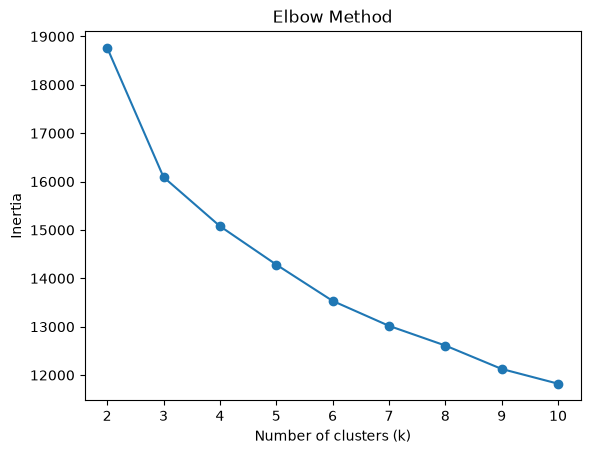

In [25]:
plt.plot(list(K), inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

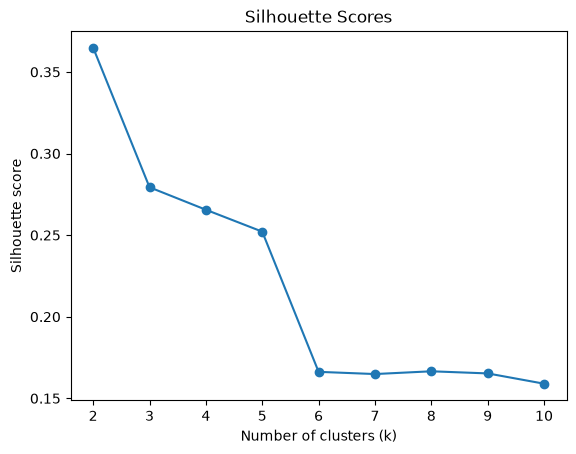

In [26]:
plt.plot(list(K), silhouettes, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette Scores")
plt.show()

The elbow bends around k=4 and the silhouette score is reasonable there, so we use 4 clusters. (Adjust this if your two plots point to a different k.)

In [27]:
model = make_pipeline(StandardScaler(), KMeans(n_clusters=4, random_state=42, n_init=10))
df["Cluster"] = model.fit_predict(X)

df["Cluster"].value_counts()

Cluster
0    1008
2     520
3     417
1     291
Name: count, dtype: int64

We have 13 features, so we cannot plot them directly. PCA compresses them into 2 principal components (combinations of the original features that capture the most variation) so the segments can be seen on a 2D plot.

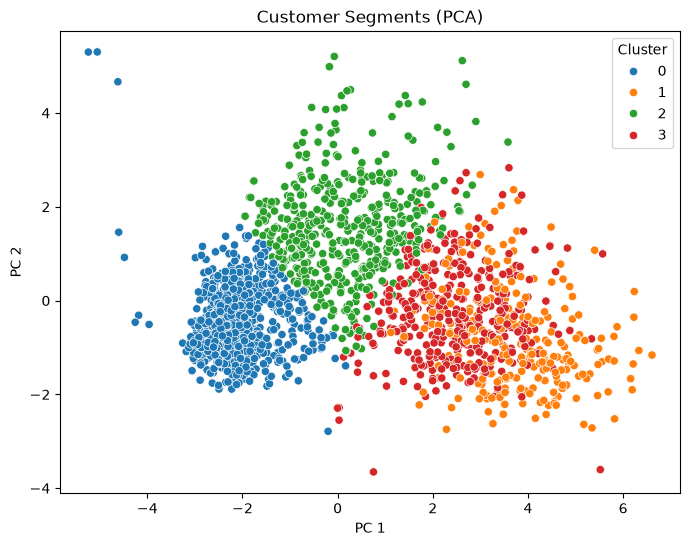

In [28]:
from sklearn.decomposition import PCA

X_scaled = model.named_steps["standardscaler"].transform(X)

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=df["Cluster"], palette="tab10")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("Customer Segments (PCA)")
plt.show()

To interpret the segments, we look at the average of each feature per cluster.

In [29]:
profile = df.groupby("Cluster")[features].mean().round(1)
profile

,Age,Income,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
Cluster,,,,,,,,,,,,,
0,43.4,34543.8,38.4,4.8,21.2,6.7,5.0,14.7,1.9,2.0,0.5,3.2,6.4
1,43.7,74014.5,508.9,98.4,422.8,132.1,99.7,95.3,1.5,5.7,5.5,8.4,3.0
2,49.8,54632.7,422.9,17.3,113.4,23.8,17.7,59.6,4.2,6.4,2.7,7.3,6.3
3,49.6,75296.7,655.5,39.2,407.6,63.3,41.6,59.6,1.5,5.1,5.9,8.5,3.0


In [30]:
df["TotalSpend"] = df[[
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds",
]].sum(axis=1)

df.groupby("Cluster")[["Age", "Income", "TotalSpend"]].mean().round(1)

,Age,Income,TotalSpend
Cluster,,,
0,43.4,34543.8,90.7
1,43.7,74014.5,1357.3
2,49.8,54632.7,654.6
3,49.6,75296.7,1266.7


Cluster Interpretation

High income / high spend - older, high income, spends a lot on wine and meat, buys through catalog and store. These are the most valuable customers.
Low income / low spend- lower income, low spending across all products, many web visits but few purchases.
Deal seekers - medium income, high NumDealsPurchases, responds to discounts.
Average / mid-tier - moderate income and spending, no strong single behavior.

Marketing Strategies

High income / high spend: loyalty or VIP program, early access to premium products, product bundles to increase basket size.
Low income / low spend: entry-level offers and reminders; they browse but do not convert, so retargeting and a simpler checkout could help.
Deal seekers: targeted discount codes and seasonal promotions, since they already buy on deals.
Average / mid-tier: cross-sell based on the categories they already buy to move them toward the high-value segment.